# This is the notebook for the project

### Data Cleaning / Combining into DataFrame used in model training

First, we read in the 'labels' - hourly energy demand. Our analysis will focus on the load zone 'COAS', which includes Houston, TX. See the image below for reference (Coast).


![Img error](https://www.ercot.com/files/assets/2023/04/26/Weather.jpg?)

In [1]:
import pandas as pd

df_demand = pd.read_csv("ercot_demand.csv")
df_demand["period"] = pd.to_datetime(df_demand["period"])
df_demand.head()

,period,COAS,EAST,FWES,NCEN,NRTH,SCEN,SOUT,WEST
0,2023-06-01 00:00:00,17008.0,2373.0,5998.0,20016.0,1692.0,11267.0,5320.0,1712.0
1,2023-06-01 01:00:00,16423.0,2247.0,5964.0,19076.0,1681.0,10901.0,5135.0,1502.0
2,2023-06-01 02:00:00,15935.0,2122.0,5921.0,18104.0,1615.0,10416.0,4956.0,1408.0
3,2023-06-01 03:00:00,15387.0,2025.0,5980.0,17320.0,1550.0,10007.0,4804.0,1352.0
4,2023-06-01 04:00:00,14520.0,1885.0,5876.0,16056.0,1442.0,9321.0,4457.0,1337.0


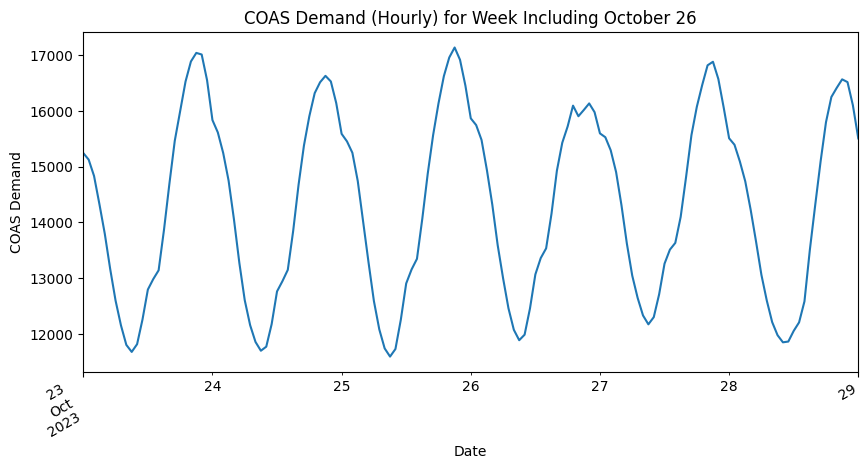

In [2]:
''' Plotting the demand for the week of oct 26, 2023 in COAS'''

df_demand_oct = df_demand[df_demand["period"].dt.month == 10]
# Find the monday-sunday week in October that includes October 26
oct_26 = df_demand_oct[df_demand_oct["period"].dt.day == 26].iloc[0]["period"]
start_of_week = oct_26 - pd.Timedelta(days=oct_26.dayofweek)  # Monday of the week
end_of_week = start_of_week + pd.Timedelta(days=6)  # Sunday of the week
df_demand_week = df_demand_oct[
    (df_demand_oct["period"] >= start_of_week) &
    (df_demand_oct["period"] <= end_of_week)
]
import matplotlib.dates as mdates

ax = df_demand_week.set_index("period")["COAS"].plot(figsize=(10, 5))
ax.set_xlabel("Date")
ax.set_ylabel("COAS Demand")
ax.set_title("COAS Demand (Hourly) for Week Including October 26")
ax.figure.autofmt_xdate()






Next, we import weather data - see [column descriptions](https://mesonet.agron.iastate.edu/request/download.phtml?network=TX_ASOS). This file contains data for all the weather stations shown in the image below.

![Img error](weather_stations.png)

In [10]:
df_weather = pd.read_csv("asos.csv")

df_weather.head()
df_weather['metar'].iloc[0]


'KARM 010515Z AUTO 09003KT 10SM CLR 22/22 A2989 RMK AO2 T02150215 TSNO'

We also consider calendar data: created using [Houston's school district calendar](https://www.fox26houston.com/news/houston-isd-calendar-for-2023-2024-academic-school-year-updated-released)

In [5]:
df_calendar = pd.read_csv('hisd_2023_2024_day_categories_with_business(1).csv')
df_calendar.head()

,day,school_category,business_category
0,2023-06-01,summer_break_weekday,normal_business_day
1,2023-06-02,summer_break_weekday,normal_business_day
2,2023-06-03,weekend_school_break,weekend
3,2023-06-04,weekend_school_break,weekend
4,2023-06-05,summer_break_weekday,normal_business_day


The most closely followed sports phenomenon in Houston is a Houston Texans game. Here, we scrape the official Houston Texans website for Texans games within the timeframe of our analysis.

In [6]:
import requests, json
from bs4 import BeautifulSoup

resp = requests.get("https://www.houstontexans.com/schedule/2023/")
soup = BeautifulSoup(resp.text, "html.parser")
games = []
for script in soup.find_all("script", type="application/ld+json"):
    data = json.loads(script.string)
    if data.get("@type") == "SportsEvent":
        is_home = data["homeTeam"]["name"] == "Houston Texans"
        opponent = data["awayTeam"]["name"] if is_home else data["homeTeam"]["name"]
        games.append({
            "datetime": data["startDate"],
            "end_datetime": data["endDate"],
            "location": "home" if is_home else "away",
            "opponent": opponent,
        })

df_texans = pd.DataFrame(games)
df_texans["datetime"] = pd.to_datetime(df_texans["datetime"])
df_texans["end_datetime"] = pd.to_datetime(df_texans["end_datetime"])
df_texans = df_texans.sort_values("datetime").reset_index(drop=True)
df_texans

,datetime,end_datetime,location,opponent
0,2023-08-10 23:00:00,2023-08-11 02:30:00,away,New England Patriots
1,2023-08-19 20:00:00,2023-08-19 23:30:00,home,Miami Dolphins
2,2023-08-28 00:00:00,2023-08-28 03:30:00,away,New Orleans Saints
3,2023-09-10 17:00:00,2023-09-10 20:30:00,away,Baltimore Ravens
4,2023-09-17 17:00:00,2023-09-17 20:30:00,home,Indianapolis Colts
5,2023-09-24 17:00:00,2023-09-24 20:30:00,away,Jacksonville Jaguars
6,2023-10-01 17:00:00,2023-10-01 20:30:00,home,Pittsburgh Steelers
7,2023-10-08 17:00:00,2023-10-08 20:30:00,away,Atlanta Falcons
8,2023-10-15 17:00:00,2023-10-15 20:30:00,home,New Orleans Saints
9,2023-10-29 17:00:00,2023-10-29 20:30:00,away,Carolina Panthers


Now that we have gathered all relevant data, we combine the datasets into one DataFrame.

In [20]:

# Standardize date columns for merging
df_calendar['day'] = pd.to_datetime(df_calendar['day'])
df_weather['valid'] = pd.to_datetime(df_weather['valid'])

# Initialize the combined dataframe with the demand labels (COAS)
df_final = df_demand[['period', 'COAS']].copy()

# Merge daily calendar data
df_final['date_key'] = df_final['period'].dt.normalize()
df_final = df_final.merge(df_calendar, left_on='date_key', right_on='day', how='left')

# Merge weather data (using 'h' instead of 'H' to avoid FutureWarning)
weather_hourly = df_weather.groupby(df_weather['valid'].dt.floor('h')).mean(numeric_only=True).reset_index()
df_final = df_final.merge(weather_hourly, left_on='period', right_on='valid', how='left')

# Add a flag for Houston Texans games
def is_game_active(ts):
    return any((ts >= df_texans['datetime']) & (ts <= df_texans['end_datetime']))
df_final['is_texans_game'] = df_final['period'].apply(is_game_active)

# Clean up temporary columns used for merging
df_final = df_final.drop(columns=['date_key', 'day', 'valid'])




Now that the data is all in one place, we can clean and apply some preprocessing for our machine learning models.

In [21]:
# Drop nonsensical, redundant, and observation-only features
# - lat/lon: nonsensical for model
# - feel/mslp: highly correlated/redundant
# - alti, skyl1-4, ice_accretion_*, peak_wind_*, metar: observation-only, not available in forecasts
cols_to_drop = [
    'lon', 'lat', 'feel', 'mslp',
    'alti',
    'skyl1', 'skyl2', 'skyl3', 'skyl4',
    'ice_accretion_1hr', 'ice_accretion_3hr', 'ice_accretion_6hr',
    'peak_wind_gust', 'peak_wind_drct', 'peak_wind_time',
    'metar'
]
df_final = df_final.drop(columns=cols_to_drop, errors='ignore')

# Datetime conversion (extract features and set index)
df_final['hour'] = df_final['period'].dt.hour
df_final['day_of_week'] = df_final['period'].dt.dayofweek
df_final['month'] = df_final['period'].dt.month
df_final = df_final.set_index('period')

# Categorical encoding
df_final = pd.get_dummies(df_final, columns=['school_category', 'business_category'], drop_first=True)

# Missing values
df_final['snowdepth'] = df_final['snowdepth'].fillna(0)
df_final = df_final.ffill()


# Boolean conversion
df_final['is_texans_game'] = df_final['is_texans_game'].astype(int)

# Time-series lag features
df_final['COAS_lag_24h'] = df_final['COAS'].shift(24)
df_final = df_final.dropna(subset=['COAS_lag_24h'])

df = df_final.copy()
df

,COAS,tmpf,dwpf,relh,drct,sknt,p01i,vsby,gust,snowdepth,...,school_category_spring_break_weekday,school_category_summer_break_weekday,school_category_thanksgiving_break_weekday,school_category_weekend_school_break,school_category_weekend_school_term,school_category_winter_break_weekday,business_category_normal_business_day,business_category_partial_business_closure,business_category_weekend,COAS_lag_24h
period,,,,,,,,,,,,,,,,,,,,,
2023-06-02 00:00:00,17702.0,72.240000,68.248000,87.696000,55.217391,1.160000,0.0,9.630000,10.0,0.0,...,False,True,False,False,False,False,True,False,False,17008.0
2023-06-02 01:00:00,16958.0,71.280769,67.873077,89.434231,56.153846,1.000000,0.0,8.807692,10.0,0.0,...,False,True,False,False,False,False,True,False,False,16423.0
2023-06-02 02:00:00,16357.0,69.957692,67.684615,92.812692,0.000000,0.307692,0.0,8.144231,10.0,0.0,...,False,True,False,False,False,False,True,False,False,15935.0
2023-06-02 03:00:00,15755.0,69.546154,67.207692,92.618077,12.307692,0.230769,0.0,6.750000,10.0,0.0,...,False,True,False,False,False,False,True,False,False,15387.0
2023-06-02 04:00:00,14859.0,69.151852,67.081481,93.400000,18.518519,0.333333,0.0,6.259259,10.0,0.0,...,False,True,False,False,False,False,True,False,False,14520.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-31 19:00:00,14515.0,74.963158,69.826316,84.360526,106.190476,8.136364,0.0,10.000000,18.6,0.0,...,False,False,False,False,False,False,True,False,False,19618.0
2024-05-31 20:00:00,15064.0,74.963158,69.826316,84.360526,106.190476,8.136364,0.0,10.000000,18.6,0.0,...,False,False,False,False,False,False,True,False,False,20132.0
2024-05-31 21:00:00,15823.0,74.963158,69.826316,84.360526,106.190476,8.136364,0.0,10.000000,18.6,0.0,...,False,False,False,False,False,False,True,False,False,20364.0


### Implementing and Evaluating ML Models

Reminder for myself: In training the model, we have to use a Time-Series validation split so the model can't cheat by just looking at the dates to better predict previous days.

The code for a XGBoost Regressor model is below. Was thinking we might use a Random Forest Regressor as a simpler baseline as well.

In the next steps, we're going to move to implement our ML model with the dataset gathered above.

Training XGBoost Regressor...
Test Mean Absolute Error (MAE): 696.33
Test Root Mean Squared Error (RMSE): 1035.15


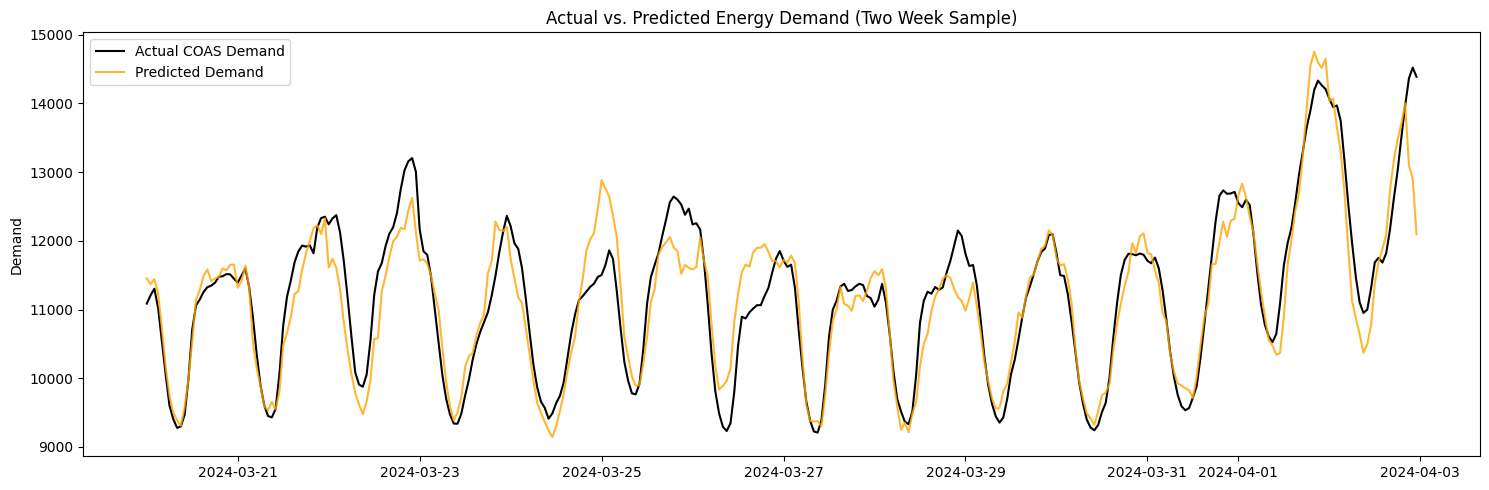

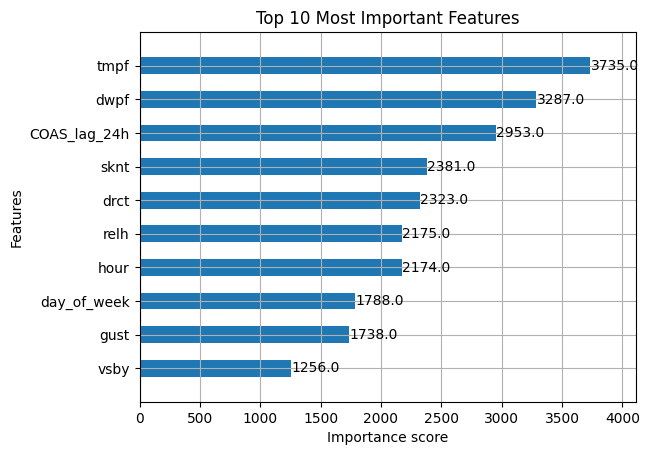

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt


y = df_final['COAS']
X = df_final.drop(columns=['COAS'])


# 1. Time-Series Split (80% Train, 20% Test)
# CRITICAL: We slice the data sequentially without shuffling
split_index = int(len(X) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# 2. Initialize and Train the XGBoost Model
print("Training XGBoost Regressor...")
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    objective='reg:squarederror',
    random_state=42
)
xgb_model.fit(X_train, y_train)

# 3. Make Predictions and Evaluate
y_pred = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"Test Mean Absolute Error (MAE): {mae:.2f}")
print(f"Test Root Mean Squared Error (RMSE): {rmse:.2f}")

# 4. Visualize the Results (First 14 days of test set)
hours_to_plot = 24 * 14
plt.figure(figsize=(15, 5))
plt.plot(y_test.index[:hours_to_plot], y_test.values[:hours_to_plot], label='Actual COAS Demand', color='black')
plt.plot(y_test.index[:hours_to_plot], y_pred[:hours_to_plot], label='Predicted Demand', color='orange', alpha=0.8)
plt.title('Actual vs. Predicted Energy Demand (Two Week Sample)')
plt.ylabel('Demand')
plt.legend()
plt.tight_layout()
plt.show()

# 5. Visualize Feature Importance
xgb.plot_importance(xgb_model, max_num_features=10, height=0.5)
plt.title('Top 10 Most Important Features')
plt.show()